In [1]:
from yahoo_oauth import OAuth2
from collections import defaultdict
from datetime import date
import yahoo_fantasy_api as yfa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sc = OAuth2(None, None, from_file='oauth2.json')

# Initialize a dictionary to hold cumulative stats per team
team_cumulative_stats = defaultdict(lambda: defaultdict(float))

[2025-09-01 12:28:50,501 DEBUG] [yahoo_oauth.oauth.__init__] Checking 
[2025-09-01 12:28:50,503 DEBUG] [yahoo_oauth.oauth.token_is_valid] ELAPSED TIME : 579584.8165633678
[2025-09-01 12:28:50,503 DEBUG] [yahoo_oauth.oauth.token_is_valid] TOKEN HAS EXPIRED
[2025-09-01 12:28:50,504 DEBUG] [yahoo_oauth.oauth.refresh_access_token] REFRESHING TOKEN


In [2]:
gm = yfa.Game(sc, 'mlb')

gm.league_ids(year=2025)

lg = gm.to_league('458.l.76357')

In [3]:
lg.player_stats(lg.player_details('Aaron Judge')[0]['player_id'],'date',date(2025, 5, 2))

[{'player_id': 9877,
  'name': 'Aaron Judge',
  'position_type': 'B',
  'H/AB': '2/4',
  'R': 1.0,
  'HR': 0.0,
  'RBI': 0.0,
  'SB': 0.0,
  'AVG': 0.5}]

In [4]:
#lg.matchups(1)['fantasy_content']['league'][1]['scoreboard']['0']['matchups']['0']['matchup']['0']['teams']['0']['team'][1]['team_stats']['stats']

In [5]:
start_week = 1
end_week = lg.current_week() 

weekly_data = []

# Initialize a dictionary to track cumulative stats
cumulative_stats = defaultdict(lambda: {'Wins': 0, 'Losses': 0, 'Ties': 0, 'HRs': 0, 'Ks': 0})

for week in range(start_week, end_week):
    matchups = lg.matchups(week)['fantasy_content']['league'][1]['scoreboard']['0']['matchups']
    
    weekly_stats = defaultdict(lambda: {'Team Name': '', 'Wins': 0, 'Losses': 0, 'Ties': 0, 'Stats': {}})

    for m_id in matchups:
        if not m_id.isdigit():
            continue
        matchup = matchups[m_id]['matchup']
        stat_winners = matchup.get('stat_winners', [])
        teams = matchup['0']['teams']
        team_keys = []

        for t_id in teams:
            if not t_id.isdigit():
                continue
            team_data = teams[t_id]['team']
            team_key = team_data[0][0]['team_key']
            team_name = team_data[0][2]['name']
            weekly_stats[team_key]['Team Name'] = team_name
            team_keys.append(team_key)
            #print(team_key,team_name)

            # Extract team_stats
            team_stats_entry = next(
                (entry['team_stats'] for entry in team_data if isinstance(entry, dict) and 'team_stats' in entry),
                None
            )

            if team_stats_entry:
                for stat in team_stats_entry['stats']:
                    stat_id = stat['stat']['stat_id']
                    value = stat['stat']['value']
                    weekly_stats[team_key]['Stats'][stat_id] = value

        for stat in stat_winners:
            stat = stat['stat_winner']
            if 'is_tied' in stat:
                for key in team_keys:
                    weekly_stats[key]['Ties'] += 1
            else:
                winner = stat['winner_team_key']
                loser = [k for k in team_keys if k != winner][0]
                weekly_stats[winner]['Wins'] += 1
                weekly_stats[loser]['Losses'] += 1

     # Update cumulative stats
    for team_key, data in weekly_stats.items():
        cumulative_stats[team_key]['Team Name'] = data['Team Name']
        cumulative_stats[team_key]['Wins'] += data['Wins']
        cumulative_stats[team_key]['Losses'] += data['Losses']
        cumulative_stats[team_key]['Ties'] += data['Ties']
        cumulative_stats[team_key]['HRs'] += int(data['Stats']['12'])
        cumulative_stats[team_key]['Ks'] += int(data['Stats']['42'])

    #print(weekly_stats)

    # Calculate winning percentages
    win_percentages = {}
    for team_key, stats in cumulative_stats.items():
        total_games = stats['Wins'] + stats['Losses'] + stats['Ties']
        win_pct = (stats['Wins'] + 0.5 * stats['Ties']) / total_games if total_games > 0 else 0
        win_percentages[team_key] = win_pct

    # Rank teams based on winning percentages
    sorted_teams = sorted(win_percentages.items(), key=lambda x: x[1], reverse=True)
    ranks = {team_key: rank + 1 for rank, (team_key, _) in enumerate(sorted_teams)}

    # Prepare weekly data
    for team_key, stats in cumulative_stats.items():
        entry = {
            'Week': week,
            'Team': stats['Team Name'],
            'Wins': stats['Wins'],
            'Losses': stats['Losses'],
            'Ties': stats['Ties'],
            'Stats': weekly_stats[team_key]['Stats'],
            'Rank': ranks[team_key],
            'cHRs': cumulative_stats[team_key]['HRs'],
            'cKs': cumulative_stats[team_key]['Ks']
        }
        weekly_data.append(entry)

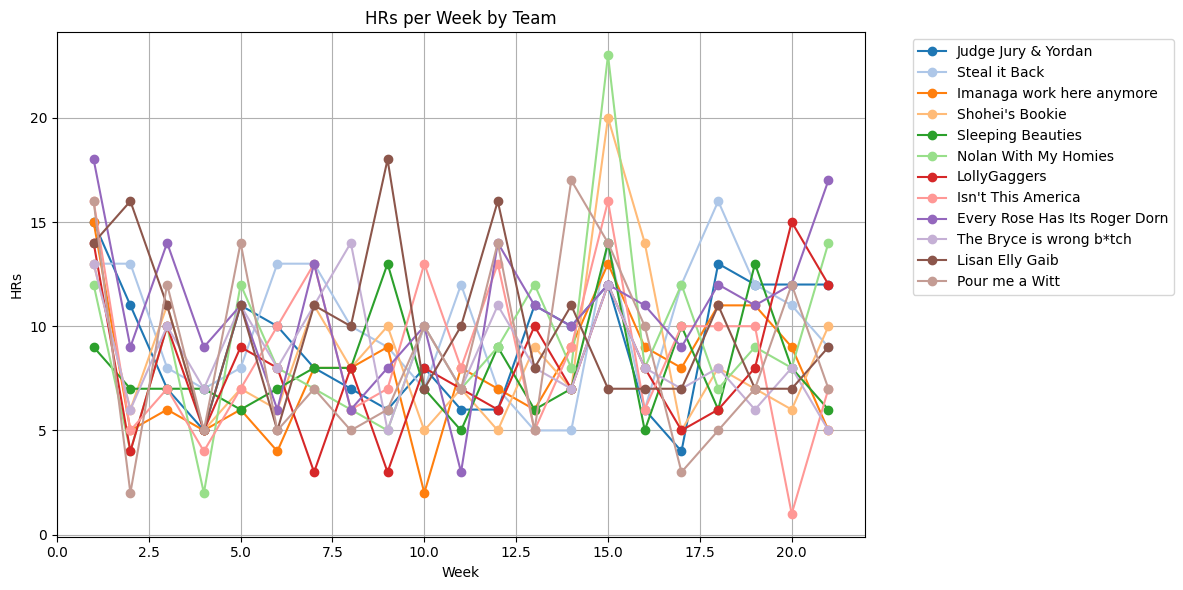

In [6]:
# Convert to DataFrame
df = pd.DataFrame(weekly_data)
homeRuns = '12'  # Example: Home Runs

palette = sns.color_palette("tab20", 12)
sns.set_palette(palette)

# Create a new column for the selected statistic
df['HRs'] = df['Stats'].apply(lambda x: float(x.get(homeRuns, 0)))

# Plot: Team Wins Over Time
plt.figure(figsize=(12, 6))
for team in df['Team'].unique():
    team_df = df[df['Team'] == team]
    plt.plot(team_df['Week'], team_df['HRs'], label=team, marker='o')

plt.title('HRs per Week by Team')
plt.xlabel('Week')
plt.ylabel('HRs')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.grid(True)
plt.show()

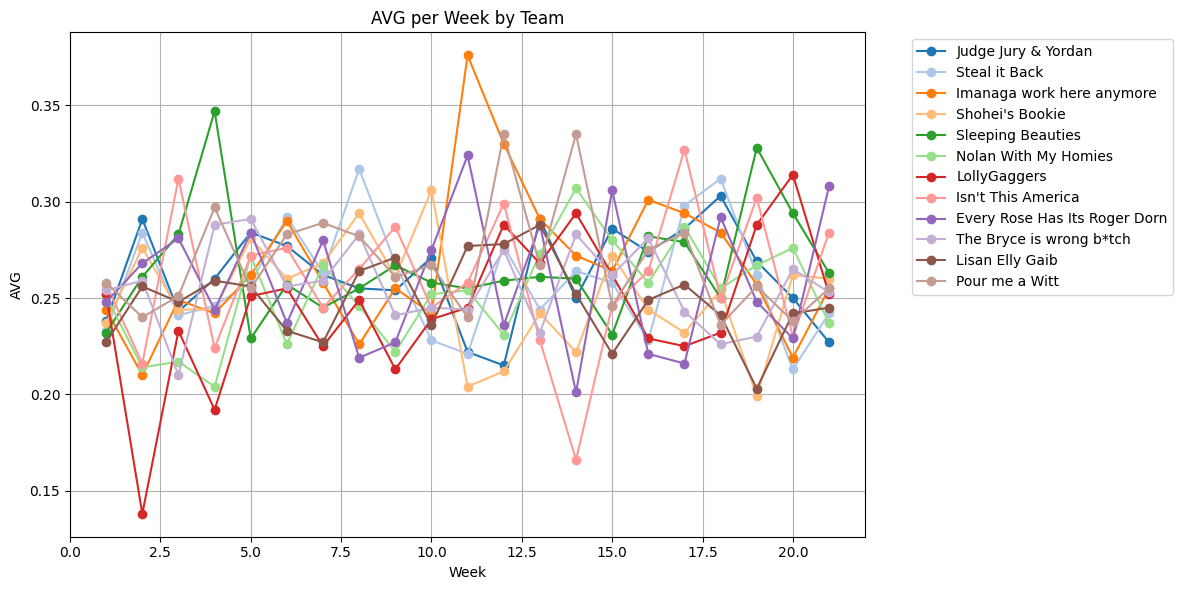

In [7]:
# Convert to DataFrame
df = pd.DataFrame(weekly_data)
average = '3'  # Example: Home Runs

palette = sns.color_palette("tab20", 12)
sns.set_palette(palette)

# Create a new column for the selected statistic
df['AVG'] = df['Stats'].apply(lambda x: float(x.get(average, 0)))

# Plot: Team Wins Over Time
plt.figure(figsize=(12, 6))
for team in df['Team'].unique():
    team_df = df[df['Team'] == team]
    plt.plot(team_df['Week'], team_df['AVG'], label=team, marker='o')

plt.title('AVG per Week by Team')
plt.xlabel('Week')
plt.ylabel('AVG')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.grid(True)
plt.show()

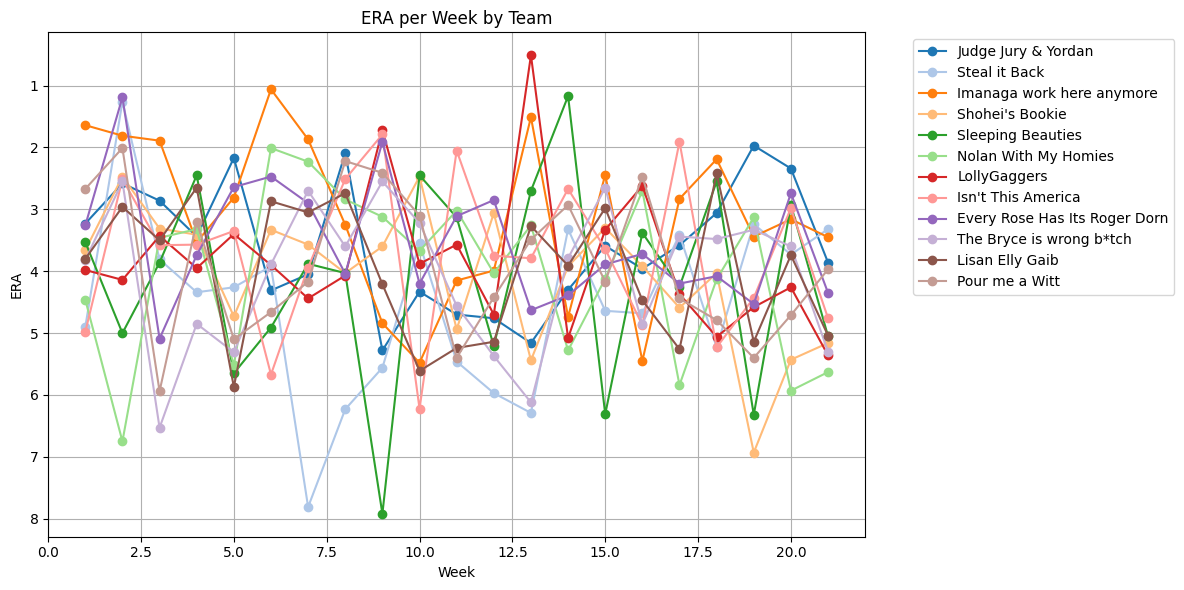

In [8]:
# Convert to DataFrame
df = pd.DataFrame(weekly_data)
ERA = '26'  # Example: Home Runs

palette = sns.color_palette("tab20", 12)
sns.set_palette(palette)

# Create a new column for the selected statistic
df['ERA'] = df['Stats'].apply(lambda x: float(x.get(ERA, 0)))

# Plot: Team Wins Over Time
plt.figure(figsize=(12, 6))
for team in df['Team'].unique():
    team_df = df[df['Team'] == team]
    plt.plot(team_df['Week'], team_df['ERA'], label=team, marker='o')

plt.title('ERA per Week by Team')
plt.xlabel('Week')
plt.ylabel('ERA')
plt.gca().invert_yaxis()
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.grid(True)
plt.show()

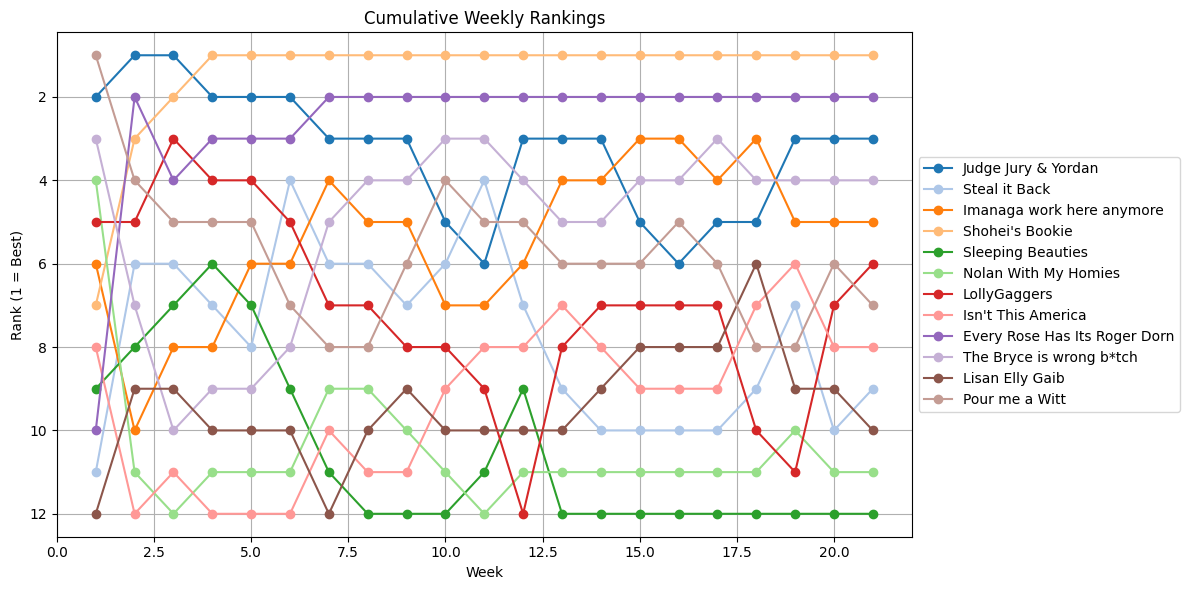

In [18]:
df = pd.DataFrame(weekly_data)

# Set a Seaborn color palette with 12 distinct colors
palette = sns.color_palette("tab20", 12)
sns.set_palette(palette)

plt.figure(figsize=(12, 6))
for i, team in enumerate(df['Team'].unique()):
    team_df = df[df['Team'] == team]
    plt.plot(team_df['Week'], team_df['Rank'], label=team, marker='o')

plt.title('Cumulative Weekly Rankings')
plt.xlabel('Week')
plt.ylabel('Rank (1 = Best)')
plt.gca().invert_yaxis()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.grid(True)
plt.show()

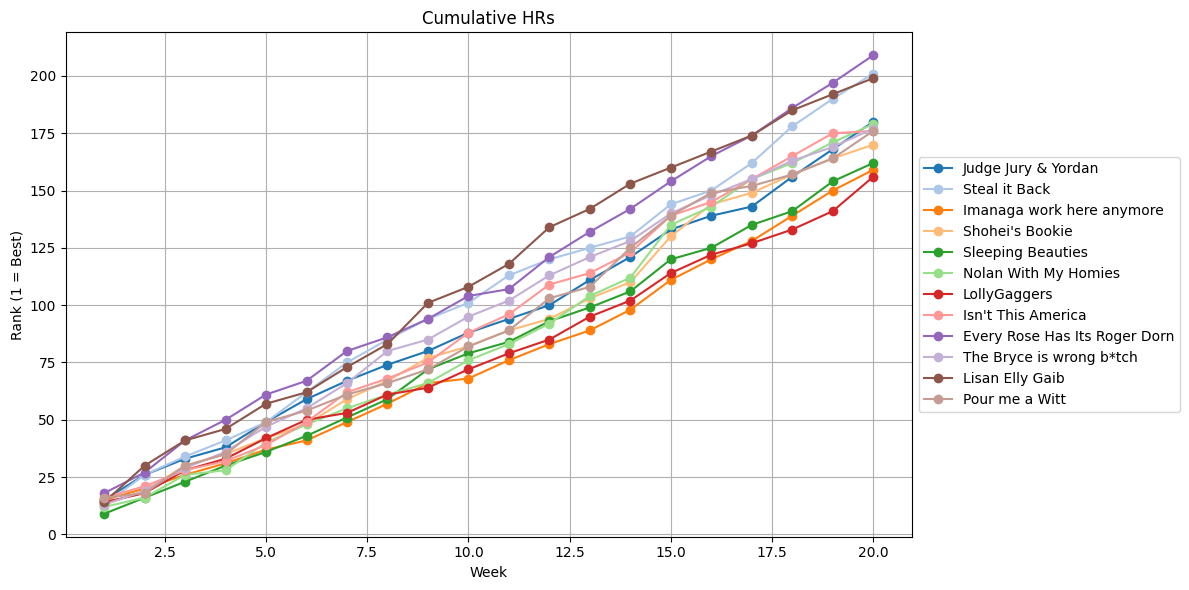

In [20]:
df = pd.DataFrame(weekly_data)

# Set a Seaborn color palette with 12 distinct colors
palette = sns.color_palette("tab20", 12)
sns.set_palette(palette)

plt.figure(figsize=(12, 6))
for i, team in enumerate(df['Team'].unique()):
    team_df = df[df['Team'] == team]
    plt.plot(team_df['Week'], team_df['cHRs'], label=team, marker='o')

plt.title('Cumulative HRs')
plt.xlabel('Week')
plt.ylabel('Rank (1 = Best)')
#plt.gca().invert_yaxis()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.grid(True)
plt.show()